Data source : https://www.kaggle.com/c/home-credit-default-risk/data

But notebook : Feature Engineering / Reduction

- utiliser les donnes agrégées précédemment
- réduire le dataframe (optimisation de futurs temps de calcul / temps de modélisation) tout en ayant le moins de données manquantes dans les features restantes
   - verification des types et choix de types plus avantageux en poids si possible
   - entrainement sur différents modèles et extraction des features notables via SHAPE ou autre (knn most important features)
   - éviter de "créer" des informations ex-nihilo avec de l'inputing : favoriser la sélection / suppression en préservant au mieux l'intégrité des données

# Imports

## libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import inspect

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
# import utils from parent directory
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

In [4]:
import gc
import time
from contextlib import contextmanager
import re

In [5]:
# https://numpy.org/doc/stable/release/2.0.0-notes.html#representation-of-numpy-scalars-changed
np.set_printoptions(legacy='1.21')

In [6]:
import mlflow
import mlflow.lightgbm
import mlflow.xgboost
import mlflow.sklearn

from mlflow import MlflowClient
from mlflow.models.signature import infer_signature
from pprint import pprint

In [7]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn import model_selection
import xgboost as xgb


from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, fbeta_score, make_scorer

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


import shap

In [8]:
import pickle

## data

In [30]:
csv_path_output = '../data/output/'
X_train_filename = 'train_df_cleaned_smote.parquet.gzip'
X_test_filename = 'test_df_cleaned.parquet.gzip'

df = pd.read_parquet(csv_path_output + X_train_filename)
X_test = pd.read_parquet(csv_path_output + X_test_filename)

In [31]:
df.head()

,EXT_SOURCE_2,EXT_SOURCE_3,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,APPROVED_AMT_DOWN_PAYMENT_MAX,...,DAYS_REGISTRATION,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN,TARGET
0,0.595281,0.706205,0.039660,0.461538,7.992843e+05,53541.0,-16961,1,0.198300,90000.0,...,-2108.0,1.137779,-2208.0,61483.410156,295.0,66693.781250,0.200000,-2021.538452,5050.211426,0.0
1,0.656764,0.071055,0.032398,4.256757,2.602840e+06,30033.0,-12187,1,0.222467,14931.0,...,-561.0,0.824513,-2604.0,35173.523438,897.0,922513.062500,0.145631,-1484.216187,8585.831055,0.0
2,0.268461,0.256706,0.047191,0.125000,3.242952e+05,10737.0,-15445,0,0.119300,22441.5,...,-1097.0,1.111116,-2289.0,13512.297852,113.0,13531.634766,0.395570,-1916.583374,0.000000,0.0
3,0.675825,0.355639,0.067940,0.000000,6.519330e+04,30573.0,-13321,0,0.104523,4500.0,...,-2951.0,1.000000,-2473.0,5926.663574,157.0,7696.529785,0.650000,-2305.454590,0.000000,0.0
4,0.579739,0.363945,0.029348,0.000000,5.055732e+05,34578.0,-19486,0,0.284593,45000.0,...,-6683.0,0.884721,-1049.0,25278.662109,289.0,190605.640625,0.103122,-559.349976,0.000000,0.0


In [32]:
df.shape

(210118, 37)

In [33]:
df.head()

,EXT_SOURCE_2,EXT_SOURCE_3,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,APPROVED_AMT_DOWN_PAYMENT_MAX,...,DAYS_REGISTRATION,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN,TARGET
0,0.595281,0.706205,0.039660,0.461538,7.992843e+05,53541.0,-16961,1,0.198300,90000.0,...,-2108.0,1.137779,-2208.0,61483.410156,295.0,66693.781250,0.200000,-2021.538452,5050.211426,0.0
1,0.656764,0.071055,0.032398,4.256757,2.602840e+06,30033.0,-12187,1,0.222467,14931.0,...,-561.0,0.824513,-2604.0,35173.523438,897.0,922513.062500,0.145631,-1484.216187,8585.831055,0.0
2,0.268461,0.256706,0.047191,0.125000,3.242952e+05,10737.0,-15445,0,0.119300,22441.5,...,-1097.0,1.111116,-2289.0,13512.297852,113.0,13531.634766,0.395570,-1916.583374,0.000000,0.0
3,0.675825,0.355639,0.067940,0.000000,6.519330e+04,30573.0,-13321,0,0.104523,4500.0,...,-2951.0,1.000000,-2473.0,5926.663574,157.0,7696.529785,0.650000,-2305.454590,0.000000,0.0
4,0.579739,0.363945,0.029348,0.000000,5.055732e+05,34578.0,-19486,0,0.284593,45000.0,...,-6683.0,0.884721,-1049.0,25278.662109,289.0,190605.640625,0.103122,-559.349976,0.000000,0.0


In [34]:
X_test.shape

(15588, 37)

In [35]:
X_test.head()

,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_1,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,...,PREV_NAME_CONTRACT_STATUS_Refused_MEAN,DAYS_REGISTRATION,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN
307507,0.789654,0.159520,0.752614,0.036147,1.571429,41195.925781,20560.5,-19241,1,0.152300,...,0.000000,-5170.0,1.044079,-1740.0,5885.132324,62.0,17397.900391,0.237342,-2195.000000,0.00000
307508,0.291656,0.432962,0.564990,0.077973,0.111111,56161.843750,17370.0,-18064,0,0.175455,...,0.000000,-9118.0,1.111173,-757.0,6240.205078,213.0,17656.244141,0.444409,-609.555542,0.00000
307510,0.509677,0.612704,0.525734,0.031123,0.265487,492310.656250,49018.5,-13976,1,0.155614,...,0.000000,-2000.0,0.000000,-1805.0,4356.731445,369.0,38988.539062,0.200000,-858.548645,622.55072
307514,0.613033,0.312365,0.565290,0.079000,0.000000,90726.750000,14220.0,-9516,0,0.085405,...,0.000000,-5063.0,1.428571,-1182.0,18145.349609,68.0,18150.705078,0.925000,-1104.599976,0.00000
307515,0.808788,0.522697,0.718507,0.079358,0.000000,462151.968750,28957.5,-12744,1,0.091929,...,0.111111,-1686.0,0.825628,-829.0,10270.043945,427.0,21199.544922,0.863260,-392.688904,0.00000


# Explo

## Valeurs manquantes

In [12]:
# https://medium.com/@kavyasree42/how-to-handle-missing-data-in-python-simple-to-advanced-techniques-machine-learning-brain-ffae3c1a694f

In [13]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))
    
# Function to calculate missing values by column
def missing_values_table(df):
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans le df avant imputation :" , round(df.isna().mean().mean(),4))
    # Total missing values
    mis_val = df.isnull().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    
    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
           "There are " + str(mis_val_table_ren_columns.shape[0]) +
           " columns that have missing values.")
    
    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [14]:
#  Statistiques sur les valeurs manquantes :
missing_values = missing_values_table(df)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Séparation du jeu de données en jeu de  training/validation et jeu de test
train_df = df[df['TARGET'].notnull()] # partie du jeu de données qui contient une target
test_df = df[df['TARGET'].isnull()] # partie du jeu de données qui n'a pas de target
print(train_df.shape, test_df.shape)
train_df["TARGET"].value_counts()/train_df.shape[0]

# Taux de valeurs manquantes :
print("Taux de valeurs manquantes dans jeu de train avant imputation :" , round(train_df.isna().mean().mean(),4))
print("Taux de valeurs manquantes dans jeu de test avant imputation :" , round(test_df.isna().mean().mean(),4))

Taux de valeurs manquantes dans le df avant imputation : 0.0
Your selected dataframe has 37 columns.
There are 0 columns that have missing values.
(210118, 37) (0, 37)
Taux de valeurs manquantes dans jeu de train avant imputation : 0.0
Taux de valeurs manquantes dans jeu de test avant imputation : nan


## Typage

In [15]:
df.head()

,EXT_SOURCE_2,EXT_SOURCE_3,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,APPROVED_AMT_DOWN_PAYMENT_MAX,...,DAYS_REGISTRATION,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN,TARGET
0,0.595281,0.706205,0.039660,0.461538,7.992843e+05,53541.0,-16961,1,0.198300,90000.0,...,-2108.0,1.137779,-2208.0,61483.410156,295.0,66693.781250,0.200000,-2021.538452,5050.211426,0.0
1,0.656764,0.071055,0.032398,4.256757,2.602840e+06,30033.0,-12187,1,0.222467,14931.0,...,-561.0,0.824513,-2604.0,35173.523438,897.0,922513.062500,0.145631,-1484.216187,8585.831055,0.0
2,0.268461,0.256706,0.047191,0.125000,3.242952e+05,10737.0,-15445,0,0.119300,22441.5,...,-1097.0,1.111116,-2289.0,13512.297852,113.0,13531.634766,0.395570,-1916.583374,0.000000,0.0
3,0.675825,0.355639,0.067940,0.000000,6.519330e+04,30573.0,-13321,0,0.104523,4500.0,...,-2951.0,1.000000,-2473.0,5926.663574,157.0,7696.529785,0.650000,-2305.454590,0.000000,0.0
4,0.579739,0.363945,0.029348,0.000000,5.055732e+05,34578.0,-19486,0,0.284593,45000.0,...,-6683.0,0.884721,-1049.0,25278.662109,289.0,190605.640625,0.103122,-559.349976,0.000000,0.0


In [16]:
df.dtypes

EXT_SOURCE_2                              float32
EXT_SOURCE_3                              float32
PAYMENT_RATE                              float32
INSTAL_DPD_MEAN                           float32
INSTAL_AMT_PAYMENT_SUM                    float32
AMT_ANNUITY                               float32
DAYS_BIRTH                                  int16
CODE_GENDER                                  int8
ANNUITY_INCOME_PERC                       float32
APPROVED_AMT_DOWN_PAYMENT_MAX             float32
DAYS_EMPLOYED_PERC                        float32
BURO_DAYS_CREDIT_MEAN                     float32
PREV_CNT_PAYMENT_MEAN                     float32
AMT_GOODS_PRICE                           float32
BURO_AMT_CREDIT_SUM_DEBT_MEAN             float32
ACTIVE_DAYS_CREDIT_MAX                    float32
ACTIVE_DAYS_CREDIT_ENDDATE_MEAN           float32
PREV_APP_CREDIT_PERC_MEAN                 float32
INSTAL_PAYMENT_PERC_MEAN                  float32
NAME_EDUCATION_TYPE_Highereducation          int8


In [18]:
df['TARGET'].value_counts(dropna=False)

0.0    105059
1.0    105059
Name: TARGET, dtype: int64

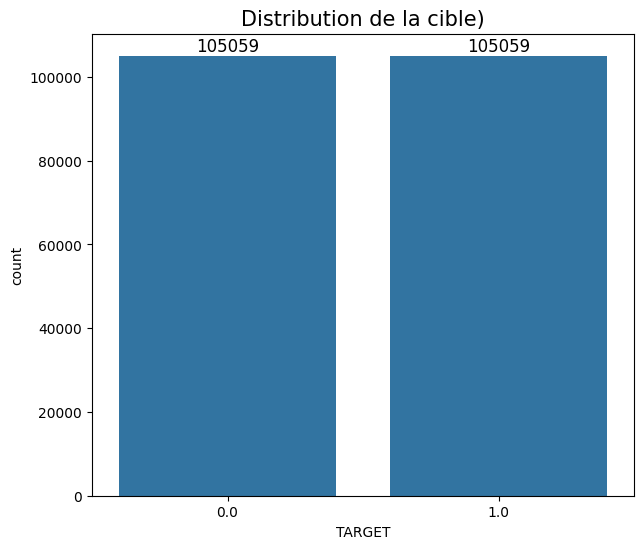

In [19]:
fig,ax=plt.subplots(figsize=(7,6))
plt.title("Distribution de la cible)", fontsize=15)
sns.countplot(x='TARGET', data=df)
for container in ax.containers:
    ax.bar_label(container,size=12,fmt='%.0f')
plt.show()

In [26]:
# Séparer les données en X_train et X_test
#X_train = df[df['TARGET'].notna()]
#X_test = df[df['TARGET'].isna()]
X_train = df

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)

Dimensions de X_train : (210118, 37)
Dimensions de X_test : (0, 37)


In [27]:
X_train['TARGET'].value_counts(dropna=False)

0.0    105059
1.0    105059
Name: TARGET, dtype: int64

In [22]:
# Vérifier les valeurs manquantes dans X_train
missing_values = X_train.isna().sum()

# Afficher les valeurs manquantes par colonne
print("Valeurs manquantes dans X_train :")
print(missing_values.sum())

Valeurs manquantes dans X_train :
0


In [23]:
# Calculer le pourcentage de valeurs manquantes par colonne
missing_percentages = X_train.isna().mean() * 100

# Créer un DataFrame pour afficher les résultats
missing_table = pd.DataFrame({
    'Feature': missing_percentages.index,
    'Missing Percentage': missing_percentages.values
}).sort_values(by='Missing Percentage', ascending=False)

# Ajouter une ligne pour le total
total_missing_percentage = missing_percentages.mean()
missing_table = pd.concat([missing_table, pd.DataFrame({
    'Feature': ['Total'],
    'Missing Percentage': [total_missing_percentage]
})], ignore_index=True)

# Afficher le tableau
pd.set_option('display.max_rows', None)
print("Pourcentage de valeurs manquantes par feature :")
print(missing_table)

Pourcentage de valeurs manquantes par feature :
                                   Feature  Missing Percentage
0                             EXT_SOURCE_2                 0.0
1      NAME_EDUCATION_TYPE_Highereducation                 0.0
2                APPROVED_CNT_PAYMENT_MEAN                 0.0
3                     BURO_DAYS_CREDIT_MAX                 0.0
4                   INSTAL_AMT_PAYMENT_MIN                 0.0
5            INSTAL_DAYS_ENTRY_PAYMENT_SUM                 0.0
6                  POS_MONTHS_BALANCE_SIZE                 0.0
7   PREV_NAME_CONTRACT_STATUS_Refused_MEAN                 0.0
8                        DAYS_REGISTRATION                 0.0
9                 PREV_APP_CREDIT_PERC_MIN                 0.0
10              APPROVED_DAYS_DECISION_MIN                 0.0
11                 INSTAL_AMT_PAYMENT_MEAN                 0.0
12                          INSTAL_DBD_SUM                 0.0
13               INSTAL_AMT_INSTALMENT_MAX                 0.0
14     

In [24]:
def missing_values_count(df):
    # Calculer le pourcentage de valeurs manquantes par colonne
    missing_percentages = df.isna().mean() * 100
    
    # Créer des bins pour les pourcentages de valeurs manquantes
    bins = [0, 0.01, 20, 40, 60, 100]  # 0%, 0-20%, 20-40%, 40-60%, 60-100%
    labels = ['0%', '0-20%', '20-40%', '40-60%', '60-100%']
    
    # Classer les caractéristiques dans les bins
    missing_bins = pd.cut(missing_percentages, bins=bins, labels=labels, right=False)
    
    # Compter le nombre de variables par bin
    bin_counts = missing_bins.value_counts().sort_index()
    
    # Calculer le pourcentage de variables dans chaque bin par rapport au total
    total_variables = len(missing_percentages)
    bin_percentages = (bin_counts / total_variables) * 100
    
    # Créer un DataFrame pour afficher les résultats
    bin_summary = pd.DataFrame({
        'Number of Variables': bin_counts,
        'Percentage of Total': bin_percentages
    })
    
    # Afficher le nombre de variables par bin et leur pourcentage par rapport au total
    print("Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :")
    print(bin_summary)

In [25]:
missing_values_count(X_train)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                        37                100.0
0-20%                      0                  0.0
20-40%                     0                  0.0
40-60%                     0                  0.0
60-100%                    0                  0.0


# Modélisations + MLflow

## Split données

In [26]:
# Séparer les caractéristiques et la cible
X = X_train.drop(columns=['TARGET'])
y = X_train['TARGET']

# Remplacer les valeurs infinies par NaN ___ "XGBoostError : Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`"
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remplacer les NaN par la moyenne de la colonne
#X.fillna(X.mean(), inplace=True)

In [27]:
X.head()

,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,PREV_CNT_PAYMENT_MEAN,AMT_GOODS_PRICE,...,TOTALAREA_MODE,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN
0,0.685827,0.755740,-5155.0,0.571429,1,0.057823,0.347794,-14822,30.0,256500.0,...,0.0410,0.877551,-583.163269,0.822953,773.684998,0.714286,-5463.0,34692.253906,24463.513672,1261.5
1,0.449313,0.477649,-2820.0,2.040816,1,0.029236,0.187625,-15030,19.5,720000.0,...,0.0573,1.051984,-646.653076,0.873210,2.700000,0.500000,-484.0,7496.685059,5301.620117,3684.5
2,0.307511,0.276441,-103.0,0.000000,1,0.050000,0.006643,-15506,9.0,450000.0,...,0.0486,1.000000,-1095.615356,0.891028,3294.270020,0.800000,-1208.0,13733.190430,13589.892578,4585.0
3,0.596865,0.619528,-967.0,0.025000,0,0.048396,0.094149,-10271,24.0,454500.0,...,0.2255,1.000000,-495.049988,0.825637,2060.685059,0.000000,-4344.0,3270.554932,2786.272949,117.5
4,0.574012,0.537070,-1620.0,0.000000,0,0.048110,0.123986,-13066,24.0,450000.0,...,0.0450,1.241498,-753.107117,0.898406,5739.345215,0.571429,-1436.0,12024.360352,16564.539062,1356.0


In [28]:
y.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: TARGET, dtype: float32

In [29]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## test MLflow

### test 1

In [29]:
# Définir les paramètres pour chaque modèle
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

rf_params = {
    'n_estimators': 100,
    'max_depth': 3,
    'random_state': 42
}

In [30]:
# Fonction pour entraîner et suivre un modèle avec MLflow
def train_and_log_model(model_name, model, params):
    with mlflow.start_run():
        # Entraîner le modèle
        model.fit(X_train, y_train)

        # Prédire les probabilités pour la classe positive
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculer le score ROC-AUC
        auc_roc = roc_auc_score(y_test, y_pred_proba)

        # Journaliser les paramètres et les métriques
        mlflow.log_params(params)
        mlflow.log_metric("auc_roc", auc_roc)

        # Prendre un exemple d'entrée pour la signature du modèle
        input_example = X_train.head(1)

        # Journaliser le modèle avec un exemple d'entrée
        if model_name == "XGBoost":
            mlflow.xgboost.log_model(model, "model", input_example=input_example)
        elif model_name == "LightGBM":
            mlflow.lightgbm.log_model(model, "model", input_example=input_example)
        elif model_name == "RandomForest":
            mlflow.sklearn.log_model(model, "model", input_example=input_example)

        print(f"{model_name} - AUC-ROC: {auc_roc}")


In [31]:
# Entraîner et suivre chaque modèle
train_and_log_model("XGBoost", xgb.XGBClassifier(**xgb_params), xgb_params)

XGBoost - AUC-ROC: 0.7539141288985675


In [32]:
train_and_log_model("LightGBM", lgb.LGBMClassifier(**lgb_params), lgb_params)

[LightGBM] [Info] Number of positive: 3913, number of negative: 48501
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8727
[LightGBM] [Info] Number of data points in the train set: 52414, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.074656 -> initscore=-2.517280
[LightGBM] [Info] Start training from score -2.517280
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM - AUC-ROC: 0.75615922517058


In [33]:
train_and_log_model("RandomForest", RandomForestClassifier(**rf_params), rf_params)

RandomForest - AUC-ROC: 0.7172751595891443


### test 2

In [41]:
# Initialiser MLflow
mlflow.set_experiment("Model_Comparison")

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

def train_model(model, param_dist, X_train, y_train, X_test, y_test, model_name):
    with mlflow.start_run():
        # RandomizedSearchCV pour le tuning des hyperparamètres
        random_search = RandomizedSearchCV(
            model, param_distributions=param_dist, n_iter=10, cv=5, scoring='precision', random_state=42
        )
        random_search.fit(X_train, y_train)

        # Enregistrer les paramètres et les métriques avec MLflow
        mlflow.log_params(random_search.best_params_)
        metrics = evaluate_model(random_search.best_estimator_, X_test, y_test)
        mlflow.log_metrics(metrics)

        # Enregistrer le modèle avec un exemple d'entrée
        input_example = X_train[:1]  # Utiliser la première ligne de X_train comme exemple d'entrée
        mlflow.sklearn.log_model(
            random_search.best_estimator_, model_name, input_example=input_example
        )

        return random_search.best_estimator_, metrics


In [42]:
# Définir les modèles et les espaces de recherche des hyperparamètres
models = {
    "XGBoost": {
        "model": XGBClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "num_leaves": [20, 30, 40, 50], 
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "min_samples_split": [2, 5, 10],
        }
    }
}

In [ ]:
# Entraîner et évaluer les modèles
for model_name, model_info in models.items():
    print(f"Training {model_name}...")
    best_model, metrics = train_model(
        model_info["model"], model_info["param_dist"], X_train, y_train, X_test, y_test, model_name
    )
    print(f"{model_name} metrics: {metrics}")

Training XGBoost...
XGBoost metrics: {'accuracy': 0.9229878917378918, 'precision': 0.375, 'recall': 0.0034762456546929316, 'f1': 0.006888633754305396}
Training LightGBM...
[LightGBM] [Info] Number of positive: 3131, number of negative: 38800
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8709
[LightGBM] [Info] Number of data points in the train set: 41931, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.074670 -> initscore=-2.517068
[LightGBM] [Info] Start training from score -2.517068
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [38]:
# afficher mlflow dans terminal : mlflow ui
# check mlflow dans dossier actuel :
# mlflow ui --backend-store-uri file://$(pwd)/mlruns

### test 3

In [29]:
# Fonction pour effectuer une recherche d'hyperparamètres et enregistrer les résultats
def grid_search_and_log_model(model, model_name, param_grid):
    print(f"Entraînement du modèle : {model_name}")
    with mlflow.start_run():
        # Ajouter un tag pour identifier le type de modèle
        mlflow.set_tag("model_type", model_name)

        # Effectuer une recherche d'hyperparamètres
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy')
        grid_search.fit(X_train, y_train)

        # Imprimer les paramètres spécifiques pour chaque run
        for i, params in enumerate(grid_search.cv_results_['params']):
            print(f"Run {i + 1} pour {model_name} avec les paramètres : {params}")

        # Prédire et calculer les métriques
        best_model = grid_search.best_estimator_
        predictions = best_model.predict(X_test)

        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions, average='weighted')
        recall = recall_score(y_test, predictions, average='weighted')
        f1 = f1_score(y_test, predictions, average='weighted')

        # Imprimer les métriques
        print(f"Modèle : {model_name} | Meilleurs paramètres : {grid_search.best_params_} \n| "
              f"Accuracy : {accuracy:.4f} | Precision : {precision:.4f} | Recall : {recall:.4f} | F1 Score : {f1:.4f}")

        # Enregistrer les paramètres et les métriques
        mlflow.log_params(grid_search.best_params_)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        

        # Enregistrer le modèle
        mlflow.sklearn.log_model(best_model, "model")

# Définir les modèles et les espaces de recherche des hyperparamètres
models = {
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "num_leaves": [20, 30, 40, 50],
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "min_samples_split": [2, 5, 10],
        }
    }
}

In [30]:
# Effectuer une recherche d'hyperparamètres et enregistrer les résultats pour chaque modèle
for model_name, config in models.items():
    grid_search_and_log_model(config["model"], model_name, config["param_dist"])

Entraînement du modèle : XGBoost
Run 1 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Run 2 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Run 3 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Run 4 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
Run 5 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Run 6 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
Run 7 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}
Run 8 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
Run 9 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300}
Run 10 pour XGBoost avec les paramètres : {'learn

2025/05/14 10:38:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Entraînement du modèle : LightGBM
[LightGBM] [Info] Number of positive: 2608, number of negative: 32334
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003957 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8701
[LightGBM] [Info] Number of data points in the train set: 34942, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.074638 -> initscore=-2.517536
[LightGBM] [Info] Start training from score -2.517536
[LightGBM] [Info] Number of positive: 2609, number of negative: 32334
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8695
[LightGBM] [Info] Number of data points in the train set: 34943, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: p

2025/05/14 10:42:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Entraînement du modèle : RandomForest


KeyboardInterrupt: 

### test 4

In [30]:
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

In [31]:
# Fonction pour effectuer une recherche d'hyperparamètres et enregistrer les résultats
def grid_search_and_log_model(model, model_name, param_grid, file_name):
    print(f"Entraînement du modèle : {model_name}")
    with mlflow.start_run():
        # Ajouter un tag pour identifier le type de modèle et le fichier initial
        mlflow.set_tag("model_type", model_name)
        mlflow.set_tag("file_name", file_name)

        # Effectuer une recherche d'hyperparamètres
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy')
        grid_search.fit(X_train, y_train)

        # Imprimer les paramètres spécifiques pour chaque run
        for i, params in enumerate(grid_search.cv_results_['params']):
            print(f"Run {i + 1} pour {model_name} avec les paramètres : {params}")

        # Prédire et calculer les métriques
        best_model = grid_search.best_estimator_
        predictions = best_model.predict(X_test)

        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions, average='weighted')
        recall = recall_score(y_test, predictions, average='weighted')
        f1 = f1_score(y_test, predictions, average='weighted')
        f2 = fbeta_score(y_test, predictions, average='weighted', beta=2)

        # Imprimer les métriques de manière compacte
        print(f"Modèle : {model_name} | Meilleurs paramètres : {grid_search.best_params_} \n| "
              f"Accuracy : {accuracy:.4f} | Precision : {precision:.4f} | Recall : {recall:.4f} | F1 Score : {f1:.4f} | F2 Score : {f2:.4f}")

        # Enregistrer les paramètres et les métriques
        mlflow.log_params(grid_search.best_params_)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("f2_score", f2)

        # Enregistrer le modèle avec un exemple d'entrée
        input_example = X_train[:1]  # Utiliser un exemple d'entrée
        mlflow.sklearn.log_model(best_model, "model", input_example=input_example)

        return best_model, accuracy, precision, f2

# Définir les modèles et les espaces de recherche des hyperparamètres
models = {
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "num_leaves": [20, 30, 40, 50],
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "min_samples_split": [2, 5, 10],
        }
    }
}

In [32]:
# Effectuer une recherche d'hyperparamètres et enregistrer les résultats pour chaque modèle
best_models = []
for model_name, config in models.items():
    best_model, accuracy, precision, f2 = grid_search_and_log_model(
        config["model"], model_name, config["param_dist"], file_name
    )
    best_models.append((best_model, accuracy, precision, f2, model_name))

    current_datetime = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    # Exporter le meilleur modèle avec Pickle
    model_filename = f"{models_dir}/best_model_{model_name.lower()}_{current_datetime}_precision_{precision:.4f}_accuracy_{accuracy:.4f}_f2_{f2:.4f}.pkl"
    with open(model_filename, 'wb') as file:
        pickle.dump(best_model, file)

    print(f"Le meilleur modèle {model_name} a été exporté dans '{model_filename}'")

Entraînement du modèle : XGBoost
Run 1 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Run 2 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Run 3 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Run 4 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
Run 5 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Run 6 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
Run 7 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}
Run 8 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
Run 9 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300}
Run 10 pour XGBoost avec les paramètres : {'learn

In [33]:
# Trouver le modèle avec la meilleure précision
best_model, best_accuracy, best_model_name = max(best_models, key=lambda x: x[1])
print(f"Le modèle avec la meilleure précision est {best_model_name} avec une précision de {best_accuracy:.4f}")

ValueError: too many values to unpack (expected 3)